In [53]:
import os
import rasterio as rio
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import matplotlib.path as mpth
from pathlib import Path

import Functions
import importlib

importlib.reload(Functions)

output_folder = Path('/home/frank/Desktop/f.chiapperino_local/VALENCIA/SCUOLA/App/Documents')
app_path = Functions.get_input_path() / 'App'
input_path = app_path / 'Documents' / 'csv'

path: /home/frank/Desktop/f.chiapperino_local/VALENCIA/SCUOLA


Collecting the moisture from the excel

In [54]:
moisture = pd.read_excel('/home/frank/Desktop/f.chiapperino_local'
                        '/VALENCIA/SCUOLA/App/Ground_Campaign_untouched/Flevoland_data/Data_25_fields/Average_Soil_moisture.xlsx',
                        header=1)
moisture.drop(columns=['Unnamed: 0','Unnamed: 1'], inplace=True)
moisture.set_index('Code',inplace=True)
moisture = moisture[moisture.index.notna()]
display(moisture)
moisture_date = list(pd.to_datetime(moisture.columns))

moisture = moisture.reset_index().melt(id_vars='Code', var_name='Date', value_name='Moist_situ')
moisture.dropna(subset='Moist_situ', inplace=True)
moisture.set_index(pd.to_datetime(moisture['Date']),inplace=True)
moisture.drop(columns='Date',inplace=True)
display(moisture)


,2017-05-13,2017-05-17,2017-05-18,2017-05-23,2017-05-30,2017-06-01,2017-06-08,2017-06-14,2017-06-15,2017-06-21,...,2017-07-17,2017-07-27,2017-08-02,2017-08-11,2017-08-16,2017-08-17,2017-08-23,2017-09-01,2017-09-07,2017-09-15
Code,,,,,,,,,,,,,,,,,,,,,
1841225.0,NaN,18.7375,NaN,18.80000,10.16250,NaN,26.70000,NaN,16.31250,13.25000,...,27.950000,30.33750,28.47500,26.33750,NaN,29.2500,27.63750,NaN,29.1125,NaN
1553694.0,NaN,19.1125,NaN,16.25000,NaN,NaN,27.51250,NaN,15.95000,6.76250,...,27.575000,30.35000,26.56250,22.70000,NaN,24.0125,21.60000,NaN,30.0875,NaN
2088262.0,NaN,NaN,NaN,18.05000,17.75000,NaN,25.15000,NaN,16.91250,13.77500,...,23.537500,28.62500,25.08750,22.95000,NaN,27.8875,21.83750,NaN,25.2375,36.0000
1896343.0,NaN,NaN,NaN,18.70000,13.35000,NaN,26.85000,NaN,18.52500,17.92500,...,26.137500,29.72500,27.96250,24.45000,NaN,27.8500,23.67500,NaN,27.9750,37.1000
1545384.0,NaN,14.7875,NaN,18.18125,NaN,NaN,23.85000,NaN,14.73125,7.51875,...,25.668750,25.08750,23.55000,23.33125,NaN,29.2562,24.88750,NaN,27.9000,33.9375
1841223.0,NaN,16.3375,16.33750,13.18750,NaN,NaN,21.86250,NaN,NaN,7.03750,...,24.262500,33.30000,26.57500,23.51250,NaN,26.5125,23.00000,NaN,21.4125,31.6250
1936133.0,NaN,NaN,NaN,14.42500,14.03125,NaN,17.02500,NaN,12.55625,8.35000,...,22.887500,23.84375,25.78125,23.25620,NaN,26.8062,23.38125,NaN,26.7250,37.6125
1631664.0,NaN,NaN,NaN,18.95000,NaN,NaN,26.45375,NaN,16.83750,NaN,...,25.812500,NaN,29.65000,23.82500,NaN,20.0750,16.57500,NaN,25.0250,40.7750
1824038.0,NaN,NaN,NaN,16.83750,13.27500,NaN,22.63750,NaN,15.47500,NaN,...,29.425000,NaN,33.05000,28.11250,NaN,NaN,21.86250,NaN,27.8125,40.1750


,Code,Moist_situ
Date,,
2017-05-17,1841225.0,18.7375
2017-05-17,1553694.0,19.1125
2017-05-17,1545384.0,14.7875
2017-05-17,1841223.0,16.3375
2017-05-18,1841223.0,16.3375
...,...,...
2017-09-15,1936135.0,34.8500
2017-09-15,2278835.0,35.6500
2017-09-15,2081268.0,38.5250


Interpolation of the SSM in situ: in this way we have a daily SSM.

In [55]:
from scipy.interpolate import pchip_interpolate

lista_dataframe_puliti = []

for c in moisture['Code'].unique():

    df = moisture[moisture['Code'] == c].copy()
    raggio_date_giornaliero = pd.date_range(start=df.index.min(), end=df.index.max(), freq='D')
    df = df.reindex(raggio_date_giornaliero)
    df.reset_index(names='Date', inplace=True)
    df['Code'] = c

    df['Umidita_PCHIP_%'] = df['Moist_situ'].interpolate(method='pchip')

#Piecewise Cubic Hermite Interpolating Polynomial (PCHIP)

    lista_dataframe_puliti.append(df)

df_generale = pd.concat(lista_dataframe_puliti, ignore_index=True)

df_generale = df_generale[['Date', 'Code', 'Moist_situ', 'Umidita_PCHIP_%']]
df_generale.sort_values(by=['Code', 'Date'], inplace=True, ignore_index=True)

#display(df_generale[df_generale['Code'] == 1698168].iloc[0:60])

Plot of the SSM for the parcel 2081267: the dots are the in-situ data and the line is the interpolated.

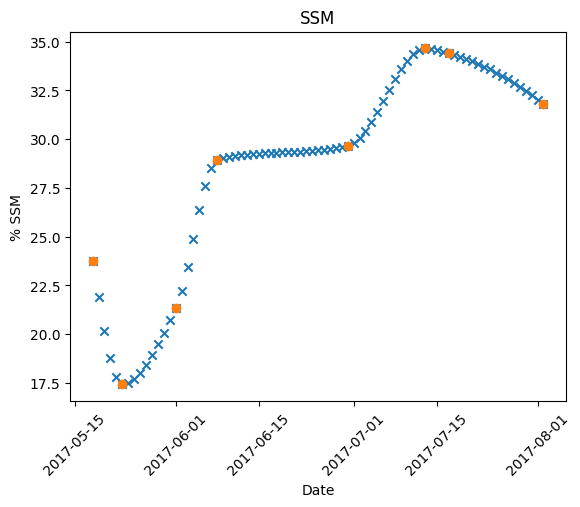

In [56]:
plt.scatter(df_generale[df_generale['Code'] == 1698168]['Date'], df_generale[df_generale['Code'] == 1698168]['Umidita_PCHIP_%'], marker='x')
plt.xlabel('Date')
plt.ylabel('% SSM')
plt.title('SSM')
plt.xticks(rotation=45)
plt.scatter(df_generale[df_generale['Code'] ==  1698168]['Date'], df_generale[df_generale['Code']==1698168]['Moist_situ'])
plt.savefig('PCHIP')

Collecting the backscatter data from a csv

In [57]:
sigma_TM = pd.DataFrame(pd.read_csv(input_path / 'TimeSeries_sigma.csv'))
sigma_TM['Date'] = pd.to_datetime(sigma_TM['Date'])
sigma_TM.drop(sigma_TM[sigma_TM['mean'] == 0].index,inplace=True)

sigma_TM = sigma_TM.sort_values(by=['Code', 'Band', 'Date'])

display(sigma_TM)

,Code,Date_Band,mean,std,Date,Band,Name,Type
1298,1545384,20170104_VH,-15.490180,1.038437,2017-01-04,VH,DB_SB2_C,Potatoes
1300,1545384,20170110_VH,-14.146261,1.136036,2017-01-10,VH,DB_SB2_C,Potatoes
1302,1545384,20170116_VH,-20.622658,0.922879,2017-01-16,VH,DB_SB2_C,Potatoes
1304,1545384,20170122_VH,-22.050701,0.694627,2017-01-22,VH,DB_SB2_C,Potatoes
1306,1545384,20170128_VH,-16.818918,0.731224,2017-01-28,VH,DB_SB2_C,Potatoes
...,...,...,...,...,...,...,...,...
935,2278835,20171206_VV,-6.205426,0.920910,2017-12-06,VV,PVD-M-C,Corn
937,2278835,20171212_VV,-11.775089,0.645342,2017-12-12,VV,PVD-M-C,Corn
939,2278835,20171218_VV,-5.921874,1.043583,2017-12-18,VV,PVD-M-C,Corn
941,2278835,20171224_VV,-6.724238,1.070252,2017-12-24,VV,PVD-M-C,Corn


Merged the SSM (interpolated) with the values of backscatter only on the dates that coincide



In [58]:
sigma_TM = pd.merge(
    sigma_TM, 
    df_generale, 
    on=['Code', 'Date'], 
    how='right' 
).dropna(subset='mean')
display(sigma_TM[(sigma_TM['Code'] == 1698168) & (sigma_TM['Band'] == 'VH')])

,Code,Date_Band,mean,std,Date,Band,Name,Type,Moist_situ,Umidita_PCHIP_%
802,1698168.0,20170522_VH,-24.888020,2.299481,2017-05-22,VH,TK_MA_C,Corn,NaN,17.784030
809,1698168.0,20170528_VH,-23.579004,2.071898,2017-05-28,VH,TK_MA_C,Corn,NaN,18.925542
816,1698168.0,20170603_VH,-21.856747,0.978037,2017-06-03,VH,TK_MA_C,Corn,NaN,23.459103
823,1698168.0,20170609_VH,-16.784010,0.766181,2017-06-09,VH,TK_MA_C,Corn,NaN,29.006227
830,1698168.0,20170615_VH,-19.871143,1.384348,2017-06-15,VH,TK_MA_C,Corn,NaN,29.248990
843,1698168.0,20170627_VH,-18.942287,1.170357,2017-06-27,VH,TK_MA_C,Corn,NaN,29.486242
850,1698168.0,20170703_VH,-15.449843,1.376613,2017-07-03,VH,TK_MA_C,Corn,NaN,30.427639
857,1698168.0,20170709_VH,-18.066310,1.087744,2017-07-09,VH,TK_MA_C,Corn,NaN,33.572379
864,1698168.0,20170715_VH,-16.945635,1.326007,2017-07-15,VH,TK_MA_C,Corn,NaN,34.566535
871,1698168.0,20170721_VH,-16.934480,1.060518,2017-07-21,VH,TK_MA_C,Corn,NaN,33.986921


Regression between SSM_PCHIP and VV and VH

In [59]:
from scipy import stats

results_regression_VV = []

for (codice, banda, name,typ), gruppo in sigma_TM.groupby(['Code', 'Band', 'Name', 'Type']):   

    VV = gruppo['mean'].values
    SSM_ret = gruppo['Umidita_PCHIP_%'].values

    if len(VV) > 2:

        slope, intercept, r_value, p_value, std_err = stats.linregress(VV, SSM_ret)        
        y_pred = slope * VV + intercept
        
        residui = SSM_ret - y_pred
        
        rmsre = np.sqrt(np.mean(residui ** 2))
        
        results_regression_VV.append({
            'Code': codice,
            'Name': name,
            'Band': banda,
            'Type': typ,
            'N_points': len(VV),
            'R_Pearson': r_value,
            'R_2': r_value ** 2,
            'P_value': p_value,
            'Slope': slope,
            'Intercept': intercept,
            'RMSRE': rmsre
        })

df_statistiche_VV = pd.DataFrame(results_regression_VV)
df_statistiche_VV.sort_values('R_2', ascending=False, inplace=True)
display(df_statistiche_VV)


,Code,Name,Band,Type,N_points,R_Pearson,R_2,P_value,Slope,Intercept,RMSRE
12,1698168.0,TK_MA_C,VH,Corn,11,0.910653,0.829289,0.000098,1.740192,61.745305,2.333544
27,1936135.0,AKW_T_C,VV,Wheat,17,0.849534,0.721708,0.000016,2.330842,54.462124,3.402975
13,1698168.0,TK_MA_C,VV,Corn,11,0.838989,0.703903,0.001245,2.102150,53.567605,3.073282
28,2041694.0,HF1-CA-C,VH,Potatoes,16,0.816064,0.665960,0.000116,1.595348,48.493415,3.316451
31,2081267.0,RBW_T_C,VV,Wheat,18,0.784821,0.615943,0.000115,2.125902,57.359695,4.052642
30,2081267.0,RBW_T_C,VH,Wheat,18,0.762210,0.580963,0.000236,1.960145,66.810430,4.233178
34,2081887.0,SB10_MA_C,VH,Corn,15,0.755746,0.571151,0.001118,1.354070,51.096598,2.010372
26,1936135.0,AKW_T_C,VH,Wheat,17,0.749902,0.562353,0.000527,2.338429,68.894938,4.267468
35,2081887.0,SB10_MA_C,VV,Corn,15,0.749213,0.561320,0.001305,1.520697,43.447733,2.033286
33,2081268.0,RBW_A_C,VV,Potatoes,18,0.738060,0.544732,0.000471,2.201008,46.652466,3.373046


In [60]:
sigma_TM['diff_mean'] = -sigma_TM.groupby(['Code', 'Band'])['mean'].diff(periods=-1)
sigma_TM['diff_lin'] = 10 ** (sigma_TM['diff_mean']/10)
sigma_TM['T'] = sigma_TM.groupby(['Code', 'Band'])['Date'].diff(periods=-1)

sigma_TM = sigma_TM[sigma_TM['Umidita_PCHIP_%'] < 55]

sigma_TM = sigma_TM.sort_values(by=['Code', 'Band', 'Date']).reset_index(drop=True)

display(sigma_TM[sigma_TM['Code'] == 1698168])

,Code,Date_Band,mean,std,Date,Band,Name,Type,Moist_situ,Umidita_PCHIP_%,diff_mean,diff_lin,T
180,1698168.0,20170522_VH,-24.888020,2.299481,2017-05-22,VH,TK_MA_C,Corn,NaN,17.784030,1.309016,1.351766,-6 days
181,1698168.0,20170528_VH,-23.579004,2.071898,2017-05-28,VH,TK_MA_C,Corn,NaN,18.925542,1.722257,1.486708,-6 days
182,1698168.0,20170603_VH,-21.856747,0.978037,2017-06-03,VH,TK_MA_C,Corn,NaN,23.459103,5.072737,3.215686,-6 days
183,1698168.0,20170609_VH,-16.784010,0.766181,2017-06-09,VH,TK_MA_C,Corn,NaN,29.006227,-3.087133,0.491232,-6 days
184,1698168.0,20170615_VH,-19.871143,1.384348,2017-06-15,VH,TK_MA_C,Corn,NaN,29.248990,0.928856,1.238470,-12 days
185,1698168.0,20170627_VH,-18.942287,1.170357,2017-06-27,VH,TK_MA_C,Corn,NaN,29.486242,3.492444,2.234830,-6 days
186,1698168.0,20170703_VH,-15.449843,1.376613,2017-07-03,VH,TK_MA_C,Corn,NaN,30.427639,-2.616467,0.547461,-6 days
187,1698168.0,20170709_VH,-18.066310,1.087744,2017-07-09,VH,TK_MA_C,Corn,NaN,33.572379,1.120675,1.294397,-6 days
188,1698168.0,20170715_VH,-16.945635,1.326007,2017-07-15,VH,TK_MA_C,Corn,NaN,34.566535,0.011155,1.002572,-6 days
189,1698168.0,20170721_VH,-16.934480,1.060518,2017-07-21,VH,TK_MA_C,Corn,NaN,33.986921,0.119403,1.027875,-6 days


In [61]:
def alpha_recursion(ssm_arr, ratio_arr,delta_t ,win=5):

    ssm_ret = ssm_arr.copy().astype(float)    

    for b in range(0, len(ssm_ret), win):

        for passo in range(1, win):
    
            i = b + passo
            if i >= len(ssm_ret) :
                break
           
            # si el delta t > 7 el counter se pone a 0 y empieza con un in-situ

            if delta_t[i-1] < -pd.Timedelta(days=7):
                continue
            if not np.isnan(ssm_ret[i-1]) and not np.isnan(ratio_arr[i-1]):
                ssm_ret[i] = ratio_arr[i-1] * ssm_ret[i-1]
            else:
                pass

                
    return ssm_ret

sigma_TM['SSM_retrieved'] = sigma_TM['Umidita_PCHIP_%'].copy()

grouped = sigma_TM.groupby(['Code', 'Band'])

for name, group in grouped:

    ssm_vals = group['Umidita_PCHIP_%'].values
    ratio_vals = group['diff_lin'].values
    delta_t_vals = group['T'].values    
    risultato = alpha_recursion(ssm_vals, ratio_vals, delta_t_vals)
    
    sigma_TM.loc[group.index, 'SSM_retrieved'] = risultato

In [62]:
display(sigma_TM[sigma_TM['Code'] == 1698168.0])

sigma_TM = sigma_TM[sigma_TM['SSM_retrieved'] < 55]

sigma_TM_copy = sigma_TM.copy()

sigma_TM = sigma_TM[sigma_TM['SSM_retrieved'] != sigma_TM['Umidita_PCHIP_%']]
sigma_TM = sigma_TM[sigma_TM['T'] > -pd.Timedelta(days=7)]
display(sigma_TM[sigma_TM['Code'] == 1698168.0])

,Code,Date_Band,mean,std,Date,Band,Name,Type,Moist_situ,Umidita_PCHIP_%,diff_mean,diff_lin,T,SSM_retrieved
180,1698168.0,20170522_VH,-24.888020,2.299481,2017-05-22,VH,TK_MA_C,Corn,NaN,17.784030,1.309016,1.351766,-6 days,17.784030
181,1698168.0,20170528_VH,-23.579004,2.071898,2017-05-28,VH,TK_MA_C,Corn,NaN,18.925542,1.722257,1.486708,-6 days,24.039852
182,1698168.0,20170603_VH,-21.856747,0.978037,2017-06-03,VH,TK_MA_C,Corn,NaN,23.459103,5.072737,3.215686,-6 days,35.740242
183,1698168.0,20170609_VH,-16.784010,0.766181,2017-06-09,VH,TK_MA_C,Corn,NaN,29.006227,-3.087133,0.491232,-6 days,114.929412
184,1698168.0,20170615_VH,-19.871143,1.384348,2017-06-15,VH,TK_MA_C,Corn,NaN,29.248990,0.928856,1.238470,-12 days,56.457012
185,1698168.0,20170627_VH,-18.942287,1.170357,2017-06-27,VH,TK_MA_C,Corn,NaN,29.486242,3.492444,2.234830,-6 days,29.486242
186,1698168.0,20170703_VH,-15.449843,1.376613,2017-07-03,VH,TK_MA_C,Corn,NaN,30.427639,-2.616467,0.547461,-6 days,65.896724
187,1698168.0,20170709_VH,-18.066310,1.087744,2017-07-09,VH,TK_MA_C,Corn,NaN,33.572379,1.120675,1.294397,-6 days,36.075896
188,1698168.0,20170715_VH,-16.945635,1.326007,2017-07-15,VH,TK_MA_C,Corn,NaN,34.566535,0.011155,1.002572,-6 days,46.696532
189,1698168.0,20170721_VH,-16.934480,1.060518,2017-07-21,VH,TK_MA_C,Corn,NaN,33.986921,0.119403,1.027875,-6 days,46.816627


,Code,Date_Band,mean,std,Date,Band,Name,Type,Moist_situ,Umidita_PCHIP_%,diff_mean,diff_lin,T,SSM_retrieved
181,1698168.0,20170528_VH,-23.579004,2.071898,2017-05-28,VH,TK_MA_C,Corn,NaN,18.925542,1.722257,1.486708,-6 days,24.039852
182,1698168.0,20170603_VH,-21.856747,0.978037,2017-06-03,VH,TK_MA_C,Corn,NaN,23.459103,5.072737,3.215686,-6 days,35.740242
187,1698168.0,20170709_VH,-18.066310,1.087744,2017-07-09,VH,TK_MA_C,Corn,NaN,33.572379,1.120675,1.294397,-6 days,36.075896
188,1698168.0,20170715_VH,-16.945635,1.326007,2017-07-15,VH,TK_MA_C,Corn,NaN,34.566535,0.011155,1.002572,-6 days,46.696532
189,1698168.0,20170721_VH,-16.934480,1.060518,2017-07-21,VH,TK_MA_C,Corn,NaN,33.986921,0.119403,1.027875,-6 days,46.816627
192,1698168.0,20170528_VV,-15.449065,1.285863,2017-05-28,VV,TK_MA_C,Corn,NaN,18.925542,1.091595,1.285759,-6 days,18.735336
193,1698168.0,20170603_VV,-14.357470,1.066032,2017-06-03,VV,TK_MA_C,Corn,NaN,23.459103,4.657967,2.922784,-6 days,24.089123
198,1698168.0,20170709_VV,-10.879458,1.319473,2017-07-09,VV,TK_MA_C,Corn,NaN,33.572379,0.402050,1.096996,-6 days,38.235874
199,1698168.0,20170715_VV,-10.477408,1.200363,2017-07-15,VV,TK_MA_C,Corn,NaN,34.566535,-0.676713,0.855714,-6 days,41.944597
200,1698168.0,20170721_VV,-11.154121,1.184361,2017-07-21,VV,TK_MA_C,Corn,NaN,33.986921,0.390707,1.094134,-6 days,35.892584


Linear regression between the SSM (obtained from the regression) and the SSM obtained with the alpha approx

In [63]:
from scipy import stats

results_regression = []

for (codice, banda, name,typ), gruppo in sigma_TM.groupby(['Code', 'Band', 'Name', 'Type']):   

    moist_situ = gruppo['Umidita_PCHIP_%'].values
    SSM_ret = gruppo['SSM_retrieved'].values

    if len(moist_situ) > 2:

        slope, intercept, r_value, p_value, std_err = stats.linregress(moist_situ, SSM_ret)        
        y_pred = slope * moist_situ + intercept
        
        residui = SSM_ret - y_pred
        
        rmsre = np.sqrt(np.mean(residui ** 2))
        
        results_regression.append({
            'Code': codice,
            'Name': name,
            'Band': banda,
            'Type': typ,
            'N_points': len(moist_situ),
            'R_Pearson': r_value,
            'R_2': r_value ** 2,
            'P_value': p_value,
            'Slope': slope,
            'Intercept': intercept,
            'RMSRE': rmsre
        })

df_statistiche = pd.DataFrame(results_regression)
df_statistiche.sort_values('R_2', ascending=False, inplace=True)
display(df_statistiche)

filename = "moisture_reg_xfield.csv"
output_path = output_folder / 'csv' / filename

df_statistiche.to_csv(output_path ,index=False, sep=';', decimal='.')

,Code,Name,Band,Type,N_points,R_Pearson,R_2,P_value,Slope,Intercept,RMSRE
13,1698168.0,TK_MA_C,VV,Corn,5,0.981655,0.963647,0.002974,1.343356,-7.046309,1.686539
25,1936134.0,AKW_SB_C,VV,Beets,8,-0.938609,0.880987,0.000552,-2.200962,75.679916,1.857167
18,1841225.0,DB_SB1_C,VH,Beets,8,-0.938519,0.880818,0.000555,-0.952144,43.814607,1.842239
24,1936134.0,AKW_SB_C,VH,Beets,8,-0.871212,0.759011,0.004838,-2.275491,76.466191,2.943581
12,1698168.0,TK_MA_C,VH,Corn,5,0.866684,0.751141,0.057250,1.132924,5.129954,4.215142
35,2081887.0,SB10_MA_C,VV,Corn,6,0.827484,0.684729,0.042076,5.130301,-111.163387,4.600057
11,1697690.0,SB8_ER_C,VV,Grassland,6,-0.782991,0.613074,0.065530,-2.253990,102.441384,4.980126
33,2081268.0,RBW_A_C,VV,Potatoes,10,0.772238,0.596352,0.008851,0.991039,-0.224476,3.105859
14,1824038.0,AKW_G2_C,VH,Grassland,9,0.754793,0.569713,0.018731,1.265278,-10.789539,5.631955
20,1896343.0,KL_MA2-C,VH,Corn,8,-0.750075,0.562612,0.032078,-2.273745,79.768495,5.576313


In [64]:
df_phen = pd.read_csv('phen_generale.csv', sep=';')
display(df_phen)

,Date,Code,Phen,Phen_PCHIP
0,2017-06-21,1545384,64.00,64.000000
1,2017-06-22,1545384,NaN,64.430864
2,2017-06-23,1545384,NaN,64.854900
3,2017-06-24,1545384,NaN,65.260470
4,2017-06-25,1545384,NaN,65.635936
...,...,...,...,...
600,2017-08-14,2278835,NaN,78.625287
601,2017-08-15,2278835,NaN,79.365602
602,2017-08-16,2278835,NaN,80.165177
603,2017-08-17,2278835,81.00,81.000000


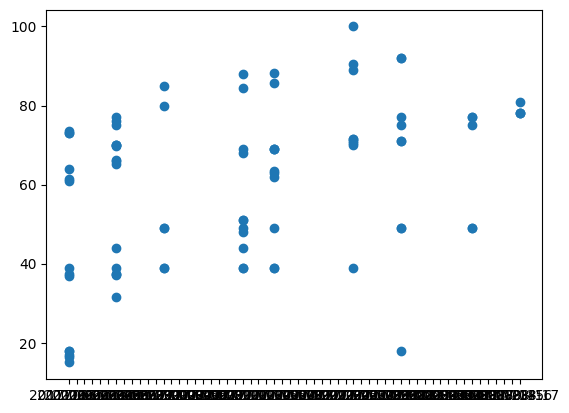

In [65]:
plt.scatter(df_phen['Date'], df_phen['Phen'])

In [66]:
df_rainfall = pd.read_csv(r'/home/frank/Desktop/f.chiapperino_local/VALENCIA/SCUOLA/App/Documents//csv/rainfall_total.csv', index_col=0)
df_rainfall.index = pd.to_datetime(df_rainfall.index, format='%Y-%m-%d')

In [67]:
display(sigma_TM[sigma_TM['Code'] == 1698168.0])

,Code,Date_Band,mean,std,Date,Band,Name,Type,Moist_situ,Umidita_PCHIP_%,diff_mean,diff_lin,T,SSM_retrieved
181,1698168.0,20170528_VH,-23.579004,2.071898,2017-05-28,VH,TK_MA_C,Corn,NaN,18.925542,1.722257,1.486708,-6 days,24.039852
182,1698168.0,20170603_VH,-21.856747,0.978037,2017-06-03,VH,TK_MA_C,Corn,NaN,23.459103,5.072737,3.215686,-6 days,35.740242
187,1698168.0,20170709_VH,-18.066310,1.087744,2017-07-09,VH,TK_MA_C,Corn,NaN,33.572379,1.120675,1.294397,-6 days,36.075896
188,1698168.0,20170715_VH,-16.945635,1.326007,2017-07-15,VH,TK_MA_C,Corn,NaN,34.566535,0.011155,1.002572,-6 days,46.696532
189,1698168.0,20170721_VH,-16.934480,1.060518,2017-07-21,VH,TK_MA_C,Corn,NaN,33.986921,0.119403,1.027875,-6 days,46.816627
192,1698168.0,20170528_VV,-15.449065,1.285863,2017-05-28,VV,TK_MA_C,Corn,NaN,18.925542,1.091595,1.285759,-6 days,18.735336
193,1698168.0,20170603_VV,-14.357470,1.066032,2017-06-03,VV,TK_MA_C,Corn,NaN,23.459103,4.657967,2.922784,-6 days,24.089123
198,1698168.0,20170709_VV,-10.879458,1.319473,2017-07-09,VV,TK_MA_C,Corn,NaN,33.572379,0.402050,1.096996,-6 days,38.235874
199,1698168.0,20170715_VV,-10.477408,1.200363,2017-07-15,VV,TK_MA_C,Corn,NaN,34.566535,-0.676713,0.855714,-6 days,41.944597
200,1698168.0,20170721_VV,-11.154121,1.184361,2017-07-21,VV,TK_MA_C,Corn,NaN,33.986921,0.390707,1.094134,-6 days,35.892584


In [68]:
phen = pd.read_csv('/home/frank/Desktop/f.chiapperino_local/VALENCIA/SCUOLA/App/Documents/csv/Averaged_Phenology_Stage.csv')
df_long = phen.melt(
    id_vars="Code",        # la colonna che resta fissa
    var_name="Date",       # nuova colonna con i nomi delle vecchie colonne (le date)
    value_name="Phen"      # nuova colonna con i valori
)
df_long["Date"] = pd.to_datetime(df_long["Date"], format="%Y-%m-%d %H:%M:%S").dt.normalize()
display(df_long)

,Code,Date,Phen
0,1545384,2017-05-18,NaN
1,1553694,2017-05-18,NaN
2,1576641,2017-05-18,NaN
3,1601502,2017-05-18,NaN
4,1631664,2017-05-18,NaN
...,...,...,...
355,2081268,2017-08-17,NaN
356,2081887,2017-08-17,78.0
357,2088262,2017-08-17,78.0
358,2278835,2017-08-17,81.0


In [69]:
phen_PCHIP = []

for c in df_long['Code'].unique():

    df = df_long[df_long['Code'] == c].copy()
    df = df.set_index('Date')                    # <-- Date diventa l'indice
    df = df.sort_index()                         # utile per l'interpolazione temporale

    raggio_date_giornaliero = pd.date_range(start=df.index.min(), end=df.index.max(), freq='D')
    df = df.reindex(raggio_date_giornaliero)
    df.reset_index(names='Date', inplace=True)   # ora 'Date' non esiste più come colonna: nessun conflitto
    df['Code'] = c
    n_punti = df['Phen'].notna().sum()

    if n_punti >= 2:
        df['Phen_PCHIP'] = df['Phen'].interpolate(method='pchip')
    else:
        # troppo pochi punti: niente interpolazione, si tiene il valore osservato
        df['Phen_PCHIP'] = df['Phen']
        print(f"Code {c}: solo {n_punti} punto/i osservato/i, PCHIP saltata")
#Piecewise Cubic Hermite Interpolating Polynomial (PCHIP)

    phen_PCHIP.append(df)

phen_generale = pd.concat(phen_PCHIP, ignore_index=True)

phen_generale = phen_generale[['Date', 'Code', 'Phen', 'Phen_PCHIP']]
phen_generale.sort_values(by=['Code', 'Date'], inplace=True, ignore_index=True)



Code 1576641: solo 0 punto/i osservato/i, PCHIP saltata
Code 1631664: solo 1 punto/i osservato/i, PCHIP saltata
Code 1697691: solo 1 punto/i osservato/i, PCHIP saltata
Code 1698168: solo 0 punto/i osservato/i, PCHIP saltata
Code 1767881: solo 0 punto/i osservato/i, PCHIP saltata
Code 1824038: solo 0 punto/i osservato/i, PCHIP saltata
Code 1889479: solo 1 punto/i osservato/i, PCHIP saltata
Code 1889482: solo 1 punto/i osservato/i, PCHIP saltata
Code 2041694: solo 0 punto/i osservato/i, PCHIP saltata
Code 2294423: solo 1 punto/i osservato/i, PCHIP saltata


In [70]:
from scipy import stats

results_regression = []

for (codice, banda, name,typ), gruppo in sigma_TM.groupby(['Code', 'Band', 'Name', 'Type']):   

    moist_situ = gruppo['Umidita_PCHIP_%'].values
    SSM_ret = gruppo['SSM_retrieved'].values

    if len(moist_situ) > 2:

        slope, intercept, r_value, p_value, std_err = stats.linregress(moist_situ, SSM_ret)        
        y_pred = slope * moist_situ + intercept
        
        residui = SSM_ret - y_pred
        
        rmsre = np.sqrt(np.mean(residui ** 2))
        
        results_regression.append({
            'Code': codice,
            'Name': name,
            'Band': banda,
            'Type': typ,
            'N_points': len(moist_situ),
            'R_Pearson': r_value,
            'R_2': r_value ** 2,
            'P_value': p_value,
            'Slope': slope,
            'Intercept': intercept,
            'RMSRE': rmsre
        })

df_statistiche = pd.DataFrame(results_regression)
df_statistiche.sort_values('R_2', ascending=False, inplace=True)
display(df_statistiche)

filename = "moisture_reg_xfield.csv"
output_path = output_folder / 'csv' / filename

df_statistiche.to_csv(output_path ,index=False, sep=';', decimal='.')

,Code,Name,Band,Type,N_points,R_Pearson,R_2,P_value,Slope,Intercept,RMSRE
13,1698168.0,TK_MA_C,VV,Corn,5,0.981655,0.963647,0.002974,1.343356,-7.046309,1.686539
25,1936134.0,AKW_SB_C,VV,Beets,8,-0.938609,0.880987,0.000552,-2.200962,75.679916,1.857167
18,1841225.0,DB_SB1_C,VH,Beets,8,-0.938519,0.880818,0.000555,-0.952144,43.814607,1.842239
24,1936134.0,AKW_SB_C,VH,Beets,8,-0.871212,0.759011,0.004838,-2.275491,76.466191,2.943581
12,1698168.0,TK_MA_C,VH,Corn,5,0.866684,0.751141,0.057250,1.132924,5.129954,4.215142
35,2081887.0,SB10_MA_C,VV,Corn,6,0.827484,0.684729,0.042076,5.130301,-111.163387,4.600057
11,1697690.0,SB8_ER_C,VV,Grassland,6,-0.782991,0.613074,0.065530,-2.253990,102.441384,4.980126
33,2081268.0,RBW_A_C,VV,Potatoes,10,0.772238,0.596352,0.008851,0.991039,-0.224476,3.105859
14,1824038.0,AKW_G2_C,VH,Grassland,9,0.754793,0.569713,0.018731,1.265278,-10.789539,5.631955
20,1896343.0,KL_MA2-C,VH,Corn,8,-0.750075,0.562612,0.032078,-2.273745,79.768495,5.576313


Here a new regression was calculaded, excluding the outliers (values that are 3*stdv away from the value found with the regression).

In [25]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from scipy import stats
from matplotlib.backends.backend_pdf import PdfPages



results_regression = []

output_folder.mkdir(parents=True, exist_ok=True)

pdf_filename = output_folder / 'Regression_Moisture_xField.pdf'


with PdfPages(pdf_filename) as pdf:

    for i, (_, row) in enumerate(df_statistiche.iterrows()):

        codice = row['Code']
        banda = row['Band']
        tipo = row['Type']
        
        dati_gruppo = sigma_TM[(sigma_TM['Code'] == codice) & (sigma_TM['Band'] == banda)].sort_values('Date')
        
        x_in_situ = dati_gruppo['Umidita_PCHIP_%'].values
        y_calcolata = dati_gruppo['SSM_retrieved'].values
        date_asse = dati_gruppo['Date'].values

        min_date = dati_gruppo['Date'].min()
        max_date = dati_gruppo['Date'].max()
        rain_filtered = df_rainfall[(df_rainfall.index >= min_date) & (df_rainfall.index <= max_date)].reset_index()
        if len(x_in_situ) > 2:
            
            # OUTLIER SEARCH
            y_pred_grezza = row['Slope'] * x_in_situ + row['Intercept']
            residui = y_calcolata - y_pred_grezza
            
            # THRESHOLD
            soglia = 3 * row['RMSRE']
            
            mask_outlier = np.abs(residui) > soglia
            mask_inlier = np.abs(residui) <= soglia
            n_outliers = np.sum(mask_outlier)
            
            x_puliti = x_in_situ[mask_inlier]
            y_puliti = y_calcolata[mask_inlier]
            
            if len(x_puliti) > 2:
                
                fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5.5))
                
                # REGRSSION W/ OUTLIER
                slope_f, intercept_f, r_f, p_f, std_err = stats.linregress(x_puliti, y_puliti)
                r2_pulito = r_f ** 2

                residui = y_puliti - x_puliti
                
                rmsre_f = np.sqrt(np.mean(residui ** 2))

                results_regression.append({
                    'Code': codice,
                    'Band': banda,
                    'Type': tipo,
                    'N_points': len(x_puliti),
                    'R_Pearson': r_f,
                    'R_2': r2_pulito,
                    'P_value': p_f,
                    'Slope': slope_f,
                    'Intercept': intercept_f,
                    'RMSRE': rmsre_f
                })

                # =================================================================
                # SUBPLOT 1: SCATTER PLOT & REGRESSIONE (ax1)
                # =================================================================
                
                # 1. Disegniamo i punti validi (Blue/Teal)
                
                sns.scatterplot(x=x_puliti, y=y_puliti, 
                                color='#1f77b4', s=60, label='Valid Data', alpha=0.8, ax=ax1)
                
                # 2. Disegniamo gli outlier rimossi (Rosso con 'X')
                if n_outliers > 0:
                    sns.scatterplot(x=x_in_situ[mask_outlier], y=y_calcolata[mask_outlier], 
                                    marker='x', color="#ca4828", s=60, label='Outliers', alpha=0.8, ax=ax1)
                
                # 3. Disegniamo la retta di regressione PULITA
                x_linea = np.linspace(x_puliti.min(), x_puliti.max(), 100)
                y_linea = slope_f * x_linea + intercept_f

                sns.lineplot(x=x_linea, y=y_linea, color="#ca4828", 
                             label=f'Cleaned Fit\n$R^2$ without outlier = {r2_pulito:.3f}', alpha=0.8, ax=ax1)
                


                ax1.fill_between(x_linea, 
                                 y_linea - std_err, 
                                 y_linea + std_err, 
                                 color="#ca4828", alpha=0.15, label='1 Std. Dev.')

                # Linea di riferimento ideale 1:1
                limiti = [min(x_in_situ.min(), y_calcolata.min()), max(x_in_situ.max(), y_calcolata.max())]
                ax1.plot(limiti, limiti, color='gray', linestyle=':', alpha=0.5, label='Ideal 1:1')
                
                # Formattazione pannello 1
                ax1.set_title(f"{codice} - {banda} - {tipo}\n($R^2$ raw: {row['R_2']:.3f})",
                              fontsize=11, fontweight='bold')
                ax1.set_xlabel("SSM In Situ ($m^3/m^3$)", fontsize=10)
                ax1.set_ylabel("SSM Retr ($m^3/m^3$)", fontsize=10)
                ax1.legend(loc='upper left', fontsize=9)
                ax1.grid(True, linestyle='--', alpha=0.5)

                # =================================================================
                # SUBPLOT 2: ANDAMENTO TEMPORALE (ax2)
                # =================================================================
                
                dati_gruppo = sigma_TM_copy[(sigma_TM_copy['Code'] == codice) & (sigma_TM_copy['Band'] == banda)].sort_values('Date')

                x_in_situ = dati_gruppo['Umidita_PCHIP_%'].values
                y_calcolata = dati_gruppo['SSM_retrieved'].values
                date_asse = dati_gruppo['Date'].values

                mask_uguali = (x_in_situ == y_calcolata)
                
                # Se c'è almeno un punto in cui coincidono, disegniamo le X rosse
                if np.any(mask_uguali):
                    ax2.scatter(date_asse[mask_uguali], y_calcolata[mask_uguali], 
                                marker='x', color="red", s=90, linewidth=2, zorder=6, label='Tie-Point')


                # Grafico linea + marker per l'umidità In Situ (usiamo il verde per distinguerlo bene)
                sns.lineplot(x=date_asse, y=x_in_situ, color='#2ca02c', marker='o', 
                             linewidth=1.8, label='SSM In Situ', ax=ax2)
                
                # Grafico linea + marker per l'umidità Stimata (riprendiamo il blu dei dati validi dello scatter)
                sns.lineplot(x=date_asse, y=y_calcolata, color='#1f77b4', marker='^', linestyle='--',
                             linewidth=1.5, label='SSM Retrieved', ax=ax2)
                
                # Opzionale ma consigliato: marchiamo con una 'X' rossa gli outlier anche sulla linea temporale della stima
                if n_outliers > 0:
                    ax2.scatter(date_asse[mask_outlier], y_calcolata[mask_outlier], 
                                marker='x', color="#ca4828", s=70, zorder=5, label='Outliers Identified')
                ax3 = ax2.twinx()

                # Usa il bar plot nativo di Matplotlib invece di Seaborn
                ax3.bar(rain_filtered['date'], rain_filtered['prec_mm'], color='blue', alpha=0.2, width=0.4) 
                # Nota: puoi regolare 'width' (es. 0.5 o 1.0) in base a quanto vuoi spesse le barre

                ax3.set_ylabel('Rain (mm)', color='blue', fontsize=12)
                ax3.tick_params(axis='y', labelcolor='blue')


                # Formattazione pannello 2
                ax2.set_title("Time Series Humidity", fontsize=11, fontweight='bold')
                ax2.set_xlabel("Date", fontsize=10)
                ax2.set_ylabel("SSM ($m^3/m^3$)", fontsize=10)
                ax2.legend(loc='upper right', fontsize=9)
                ax2.grid(True, linestyle='--', alpha=0.5)
                
                # Ruotiamo le date sull'asse X per non farle sovrapporre
                ax2.tick_params(axis='x', rotation=30)
                
                # Compattiamo il layout globale prima del salvataggio
                plt.tight_layout()
                
                # Salva la figura a due pannelli nella pagina corrente del PDF
                pdf.savefig()
                plt.close()


In [26]:
df_statistiche = pd.DataFrame(results_regression)
display(df_statistiche)


,Code,Band,Type,N_points,R_Pearson,R_2,P_value,Slope,Intercept,RMSRE
0,1698168.0,VV,Corn,5,0.981655,0.963647,0.002974,1.343356,-7.046309,4.006211
1,1936134.0,VV,Beets,8,-0.938609,0.880987,0.000552,-2.200962,75.679916,8.718498
2,1841225.0,VH,Beets,8,-0.938519,0.880818,0.000555,-0.952144,43.814607,12.035672
3,1936134.0,VH,Beets,8,-0.871212,0.759011,0.004838,-2.275491,76.466191,9.705765
4,1698168.0,VH,Corn,5,0.866684,0.751141,0.057250,1.132924,5.129954,9.949757
5,2081887.0,VV,Corn,6,0.827484,0.684729,0.042076,5.130301,-111.163387,9.712095
6,1697690.0,VV,Grassland,6,-0.782991,0.613074,0.065530,-2.253990,102.441384,10.475428
7,2081268.0,VV,Potatoes,10,0.772238,0.596352,0.008851,0.991039,-0.224476,3.138841
8,1824038.0,VH,Grassland,9,0.754793,0.569713,0.018731,1.265278,-10.789539,7.035144
9,1896343.0,VH,Corn,8,-0.750075,0.562612,0.032078,-2.273745,79.768495,11.180901


In [27]:
pivot = df_statistiche.pivot_table(index=['Type', 'Code'], columns='Band',values=['R_2', 'RMSRE', 'R_Pearson'])
display(pivot)

RMSRE                  R_2           R_Pearson  \
Band                        VH         VV        VH        VV        VH   
Type      Code                                                            
Beets     1553694.0  13.868911  13.024104  0.062784  0.047156 -0.250567   
          1601502.0  10.208009   9.686188  0.000012  0.157295 -0.003482   
          1841225.0  12.035672  15.723138  0.880818  0.461597 -0.938519   
          1936134.0   9.705765   8.718498  0.759011  0.880987 -0.871212   
Corn      1698168.0   9.949757   4.006211  0.751141  0.963647  0.866684   
          1896343.0  11.180901  10.729354  0.562612  0.119398 -0.750075   
          2081887.0   8.515727   9.712095  0.381065  0.684729  0.617305   
          2278835.0   9.394875   9.436743  0.187174  0.086932 -0.432636   
Grassland 1631664.0   6.535602   4.494537  0.384398  0.438427  0.619998   
          1697689.0   8.278487  13.261370  0.166744  0.451592 -0.408344   
          1697690.0   7.818256  10.475428  0.032578  0.613074 -0.180494   
          1824038.0   7.035144   8.520626  0.569713  0.328800  0.754793   
          2088262.0   8.326586   9.177111  0.013633  0.013463  0.116760   
Potatoes  1545384.0   9.827877  11.823410  0.318129  0.049303 -0.564029   
          1936133.0   6.571231  11.798310  0.096163  0.433910 -0.310102   
          2041694.0  12.931317   5.676770  0.264767  0.544769  0.514555   
          2081268.0   6.926176   3.138841  0.030427  0.596352  0.174435   
Wheat     1841223.0   9.234950  12.822329  0.017877  0.136537 -0.133707   
          1936135.0  14.589938   6.883940  0.290962  0.006845 -0.539409   
          2081267.0  13.370230  10.993398  0.000348  0.132288 -0.018643   

                               
Band                       VV  
Type      Code                 
Beets     1553694.0 -0.217154  
          1601502.0  0.396605  
          1841225.0 -0.679409  
          1936134.0 -0.938609  
Corn      1698168.0  0.981655  
          1896343.0 -0.345540  
          2081887.0  0.827484  
          2278835.0 -0.294843  
Grassland 1631664.0  0.662138  
          1697689.0 -0.672006  
          1697690.0 -0.782991  
          1824038.0  0.573411  
          2088262.0 -0.116032  
Potatoes  1545384.0 -0.222043  
          1936133.0 -0.658719  
          2041694.0  0.738085  
          2081268.0  0.772238  
Wheat     1841223.0 -0.369509  
          1936135.0 -0.082734  
          2081267.0 -0.363714

In [28]:
pivot_ordinata = pivot.sort_values(by=['Type', ('R_2', 'VV')], ascending=[False, False])
display(pivot_ordinata)

RMSRE                  R_2           R_Pearson  \
Band                        VH         VV        VH        VV        VH   
Type      Code                                                            
Wheat     1841223.0   9.234950  12.822329  0.017877  0.136537 -0.133707   
          2081267.0  13.370230  10.993398  0.000348  0.132288 -0.018643   
          1936135.0  14.589938   6.883940  0.290962  0.006845 -0.539409   
Potatoes  2081268.0   6.926176   3.138841  0.030427  0.596352  0.174435   
          2041694.0  12.931317   5.676770  0.264767  0.544769  0.514555   
          1936133.0   6.571231  11.798310  0.096163  0.433910 -0.310102   
          1545384.0   9.827877  11.823410  0.318129  0.049303 -0.564029   
Grassland 1697690.0   7.818256  10.475428  0.032578  0.613074 -0.180494   
          1697689.0   8.278487  13.261370  0.166744  0.451592 -0.408344   
          1631664.0   6.535602   4.494537  0.384398  0.438427  0.619998   
          1824038.0   7.035144   8.520626  0.569713  0.328800  0.754793   
          2088262.0   8.326586   9.177111  0.013633  0.013463  0.116760   
Corn      1698168.0   9.949757   4.006211  0.751141  0.963647  0.866684   
          2081887.0   8.515727   9.712095  0.381065  0.684729  0.617305   
          1896343.0  11.180901  10.729354  0.562612  0.119398 -0.750075   
          2278835.0   9.394875   9.436743  0.187174  0.086932 -0.432636   
Beets     1936134.0   9.705765   8.718498  0.759011  0.880987 -0.871212   
          1841225.0  12.035672  15.723138  0.880818  0.461597 -0.938519   
          1601502.0  10.208009   9.686188  0.000012  0.157295 -0.003482   
          1553694.0  13.868911  13.024104  0.062784  0.047156 -0.250567   

                               
Band                       VV  
Type      Code                 
Wheat     1841223.0 -0.369509  
          2081267.0 -0.363714  
          1936135.0 -0.082734  
Potatoes  2081268.0  0.772238  
          2041694.0  0.738085  
          1936133.0 -0.658719  
          1545384.0 -0.222043  
Grassland 1697690.0 -0.782991  
          1697689.0 -0.672006  
          1631664.0  0.662138  
          1824038.0  0.573411  
          2088262.0 -0.116032  
Corn      1698168.0  0.981655  
          2081887.0  0.827484  
          1896343.0 -0.345540  
          2278835.0 -0.294843  
Beets     1936134.0 -0.938609  
          1841225.0 -0.679409  
          1601502.0  0.396605  
          1553694.0 -0.217154